In [1]:
from poe import PortfolioOptimizationEnv
from utils import Utils
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
df = Utils.create_df("./data/anonymized_data/")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 251100 entries, 0 to 251099
Data columns (total 8 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   index   251100 non-null  int64         
 1   date    251100 non-null  datetime64[us]
 2   open    251100 non-null  float64       
 3   high    251100 non-null  float64       
 4   low     251100 non-null  float64       
 5   close   251100 non-null  float64       
 6   volume  251100 non-null  int64         
 7   tic     251100 non-null  str           
dtypes: datetime64[us](1), float64(4), int64(2), str(1)
memory usage: 15.3 MB


Let's use A library for getting asset features

In [3]:
from stockstats import wrap
df = wrap(df)
df.head()

,index,open,high,low,close,volume,tic
date,,,,,,,
2016-01-25,0,29.178415,29.181290,28.514486,28.580592,249449990,Asset_001
2016-01-25,0,63.053655,63.915578,62.701607,62.871562,25513968,Asset_002
2016-01-25,0,36.937133,37.248525,36.244414,36.329153,45020316,Asset_003
2016-01-25,0,34.209639,34.810891,34.013417,34.126115,63789141,Asset_004
2016-01-25,0,0.908495,0.919037,0.905940,0.907856,207372128,Asset_005


In [4]:
rsi = df['rsi']
rsi_6 = df['rsi_6']
cci = df['cci_10']
macd = df['macd']
sma = df['close_20_sma']
ema = df['close_20_ema']
adx = df['adx']

In [5]:
for col in df.columns:
    print(col)

index
open
high
low
close
volume
tic
rsi
rsi_6
cci_10
macd
macds
macdh
close_20_sma
close_20_ema
dx
adx
adxr


In [6]:
TRAIN_WINDOW = 100 # sessions
TEST_WINDOW = 10 # sessions

train, test = Utils.train_test_split(df, TRAIN_WINDOW, TEST_WINDOW)
test.reset_index(inplace=True)
train.reset_index(inplace=True)

In [7]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          10000 non-null  datetime64[us]
 1   index         10000 non-null  int64         
 2   open          10000 non-null  float64       
 3   high          10000 non-null  float64       
 4   low           10000 non-null  float64       
 5   close         10000 non-null  float64       
 6   volume        10000 non-null  int64         
 7   tic           10000 non-null  str           
 8   rsi           10000 non-null  float64       
 9   rsi_6         10000 non-null  float64       
 10  cci_10        10000 non-null  float64       
 11  macd          10000 non-null  float64       
 12  macds         10000 non-null  float64       
 13  macdh         10000 non-null  float64       
 14  close_20_sma  10000 non-null  float64       
 15  close_20_ema  10000 non-null  float64       
 16

I first want to check if I am able to connect my dataframe to Fin-RL meta Portfolio Optimization Environment

In [8]:
df = df.reset_index()

env = PortfolioOptimizationEnv(
    df = df,
    initial_amount = 10000,
    order_df = True,
    comission_fee_pct=0.001,
    comission_fee_model="trf",
    features = ["close", "high", "low", 'volume', 'rsi', 'rsi_6', 'cci_10', 'macd', 'close_20_sma', 'close_20_ema', 'adx']
)

Normalizing ['close', 'high', 'low', 'volume', 'rsi', 'rsi_6', 'cci_10', 'macd', 'close_20_sma', 'close_20_ema', 'adx'] by previous time...


In [13]:
# Equal Weight Portfolio
def equal_weight_portfolio(env):
    n = env._stock_dim
    weights = np.zeros(n + 1, dtype=np.float32)
    weights[1:] = 1/n
    weights /= weights.sum()
    rewards = []

    while True:
        obs, reward, terminated, truncated, info = env.step(weights)
        rewards.append(reward)
        if terminated:
            break
    
    return rewards

In [ ]:
# Testing Equal Portfolio Weights
obs, info = env.reset()
n = env._stock_dim
weights = np.zeros(n + 1, dtype=np.float32)
weights[1:] = 1/n
weights /= weights.sum()

rewards = []

train_env = PortfolioOptimizationEnv(
    df = train,
    initial_amount = 10000,
    order_df = True,
    comission_fee_pct=0.001,
    comission_fee_model="trf",
    features = ["close", "high", "low", 'volume', 'rsi', 'rsi_6', 'cci_10', 'macd', 'close_20_sma', 'close_20_ema', 'adx']
)

Normalizing ['close', 'high', 'low', 'volume', 'rsi', 'rsi_6', 'cci_10', 'macd', 'close_20_sma', 'close_20_ema', 'adx'] by previous time...


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


Initial portfolio value:10000
Final portfolio value: 11448.7451171875
Final accumulative portfolio value: 1.1448744535446167
Maximum DrawDown: -0.903244326171875
Sharpe ratio: 2.488649014606743


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


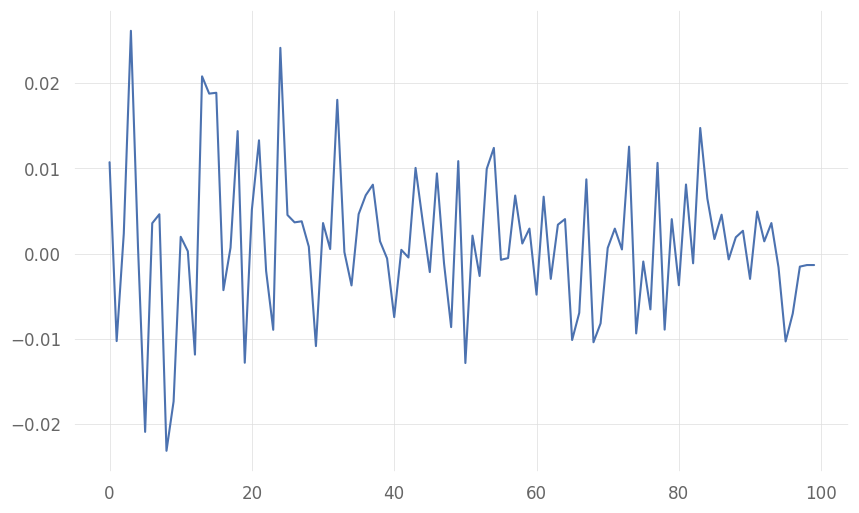

In [10]:
plt.plot(rewards) # daily log returns

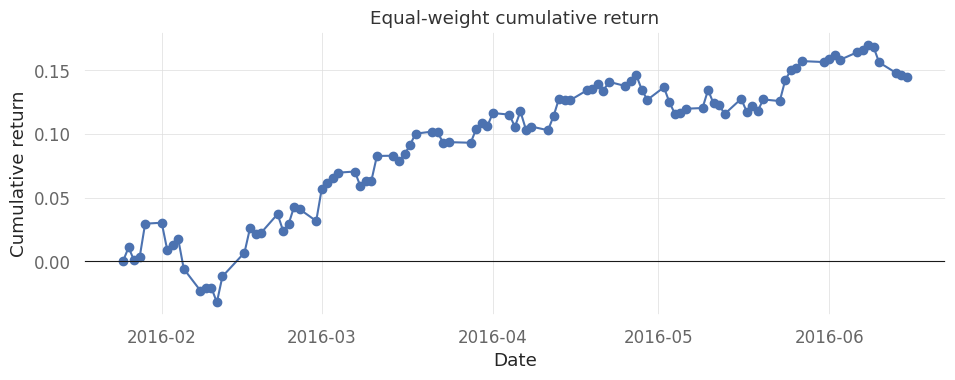

In [12]:
values = np.asarray(train_env._asset_memory["final"], dtype=float)
dates = pd.to_datetime(train_env._date_memory)
cumulative = values / values[0] - 1
plt.figure(figsize=(10, 4))
plt.plot(dates, cumulative, marker="o")
plt.axhline(0, color="k", lw=0.8)
plt.title("Equal-weight cumulative return")
plt.xlabel("Date")
plt.ylabel("Cumulative return")
plt.tight_layout()
plt.show()

Performance of Equal Weight Cumulative Return over the training data

In [16]:
# Test on the test env
test_env = PortfolioOptimizationEnv(
    df = test,
    initial_amount = 10000,
    order_df = True,
    comission_fee_pct=0.001,
    comission_fee_model="trf",
)


rewards = equal_weight_portfolio(test_env)

Normalizing ['close', 'high', 'low'] by previous time...


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


Initial portfolio value:10000
Final portfolio value: 9989.138671875
Final accumulative portfolio value: 0.9989138841629028
Maximum DrawDown: -0.90389447265625
Sharpe ratio: 0.032737729174380066


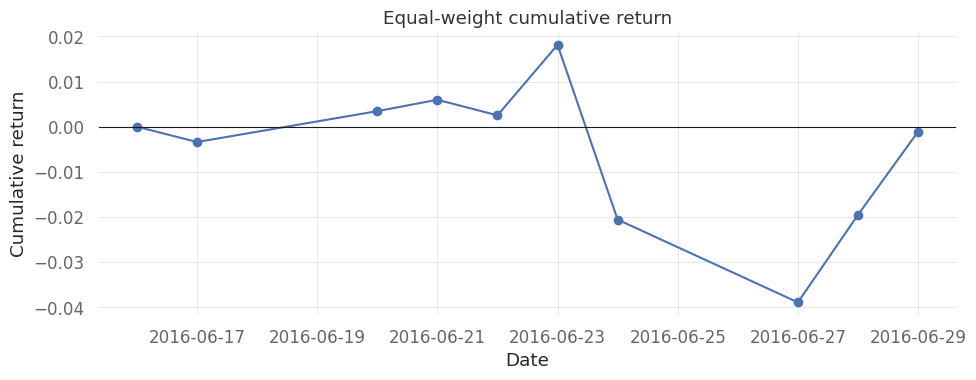

In [17]:
values = np.asarray(test_env._asset_memory["final"], dtype=float)
dates = pd.to_datetime(test_env._date_memory)
cumulative = values / values[0] - 1
plt.figure(figsize=(10, 4))
plt.plot(dates, cumulative, marker="o")
plt.axhline(0, color="k", lw=0.8)
plt.title("Equal-weight cumulative return")
plt.xlabel("Date")
plt.ylabel("Cumulative return")
plt.tight_layout()
plt.show()